**Load data and assign column names**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

col_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train = pd.read_csv('KDDTrain+.txt', names=col_names)
test  = pd.read_csv('KDDTest+.txt', names=col_names)

print(train.shape, test.shape)
print(train.head())

(125973, 43) (22544, 43)
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                      

**Map attack types to categories**

In [ ]:
attack_map = {
    'DoS': ['apache2','back','mailbomb','processtable','snmpgetattack','teardrop',
            'smurf','land','neptune','pod','udpstorm'],
    'Probe': ['nmap','ipsweep','portsweep','satan','mscan','saint'],
    'R2L': ['ftp_write','guess_passwd','snmpguess','imap','spy','warezclient',
            'warezmaster','multihop','phf','named','sendmail','xlock','xsnoop','worm'],
    'U2R': ['ps','buffer_overflow','perl','rootkit','loadmodule','xterm',
            'sqlattack','httptunnel']
}

def map_attack(label):
    if label == 'normal':
        return 'normal'
    for cat, attacks in attack_map.items():
        if label in attacks:
            return cat
    return 'other'

train['category'] = train['label'].apply(map_attack)
test['category']  = test['label'].apply(map_attack)

# Binary label: 0 = normal, 1 = attack
train['binary'] = train['label'].apply(lambda x: 0 if x == 'normal' else 1)
test['binary']  = test['label'].apply(lambda x: 0 if x == 'normal' else 1)

**Exploratory data analysis**

category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64
category
normal    9711
DoS       7636
R2L       2576
Probe     2421
U2R        200
Name: count, dtype: int64


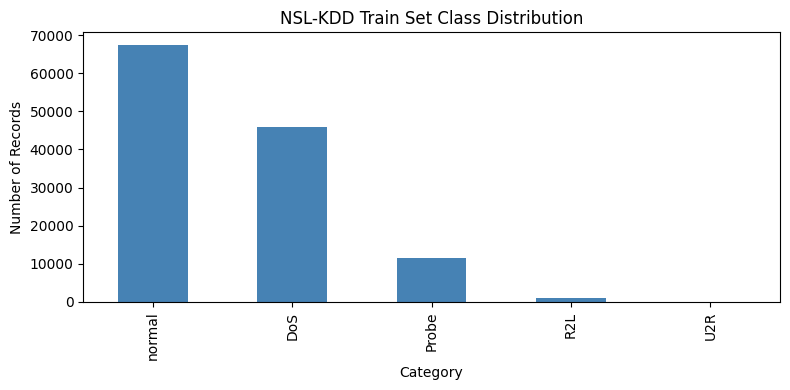

In [ ]:
print(train['category'].value_counts())
print(test['category'].value_counts())
plt.figure(figsize=(8,4))
train['category'].value_counts().plot(kind='bar', color='steelblue')
plt.title('NSL-KDD Train Set Class Distribution')
plt.xlabel('Category')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

**Preprocessing pipeline**

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cat_cols = ['protocol_type', 'service', 'flag']
num_cols = [c for c in col_names if c not in cat_cols + ['label','difficulty','category','binary']]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

**Dataset partitioning**

In [ ]:
from sklearn.model_selection import train_test_split
X_train = train[num_cols + cat_cols]
y_train = train['category']
X_test  = test[num_cols + cat_cols]
y_test  = test['category']
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
print(X_tr.shape, X_val.shape, X_test.shape)

(100778, 41) (25195, 41) (22544, 41)


**Build and train models**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', gamma='scale'),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}
results = {}
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average='weighted')
    results[name] = {'Accuracy': acc, 'F1': f1}
    print(f"\n===== {name} =====")
    print(classification_report(y_test, pred))
    print(confusion_matrix(y_test, pred))


===== Logistic Regression =====
              precision    recall  f1-score   support

         DoS       0.92      0.81      0.86      7636
       Probe       0.88      0.78      0.82      2421
         R2L       0.54      0.01      0.02      2576
         U2R       0.83      0.07      0.14       200
      normal       0.67      0.93      0.78      9711

    accuracy                           0.76     22544
   macro avg       0.77      0.52      0.52     22544
weighted avg       0.76      0.76      0.72     22544

[[6208    5    0    0 1423]
 [ 119 1880   23    0  399]
 [   3    5   31    1 2536]
 [   2    2    1   15  180]
 [ 419  255    2    2 9033]]

===== Decision Tree =====
              precision    recall  f1-score   support

         DoS       0.96      0.81      0.88      7636
       Probe       0.77      0.65      0.71      2421
         R2L       0.94      0.10      0.18      2576
         U2R       0.74      0.09      0.15       200
      normal       0.67      0.96      

                 Model  Accuracy        F1
0        Decision Tree  0.768586  0.736162
1                  KNN  0.767255  0.725306
2  Logistic Regression  0.761489  0.718870
3        Random Forest  0.751419  0.712124
4                  SVM  0.747738  0.714134
5          Naive Bayes  0.619233  0.591089


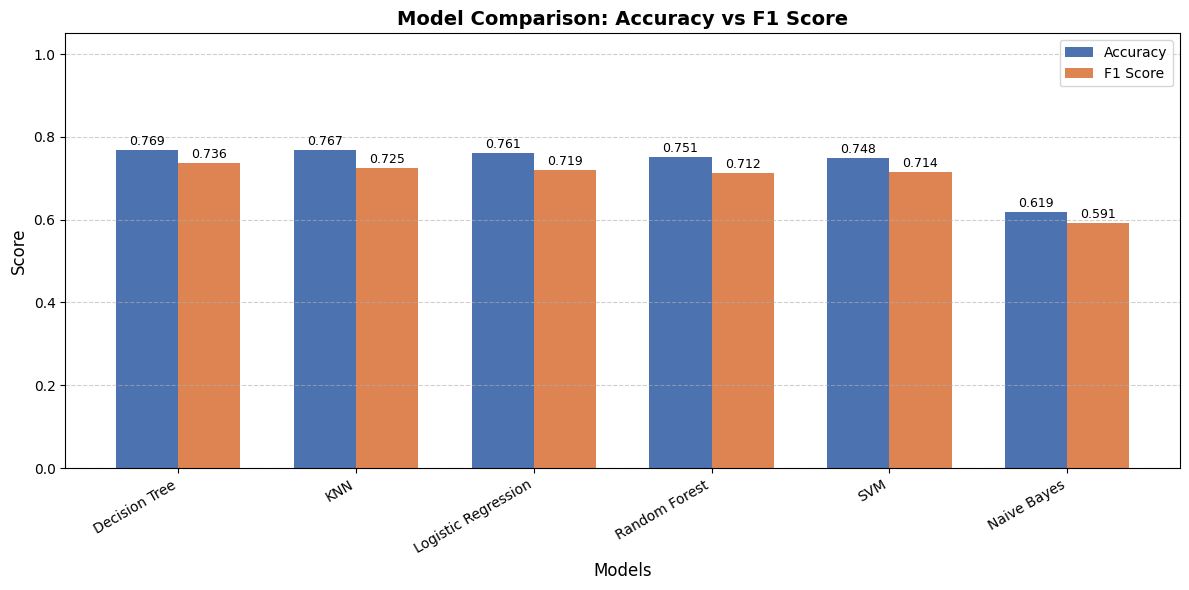

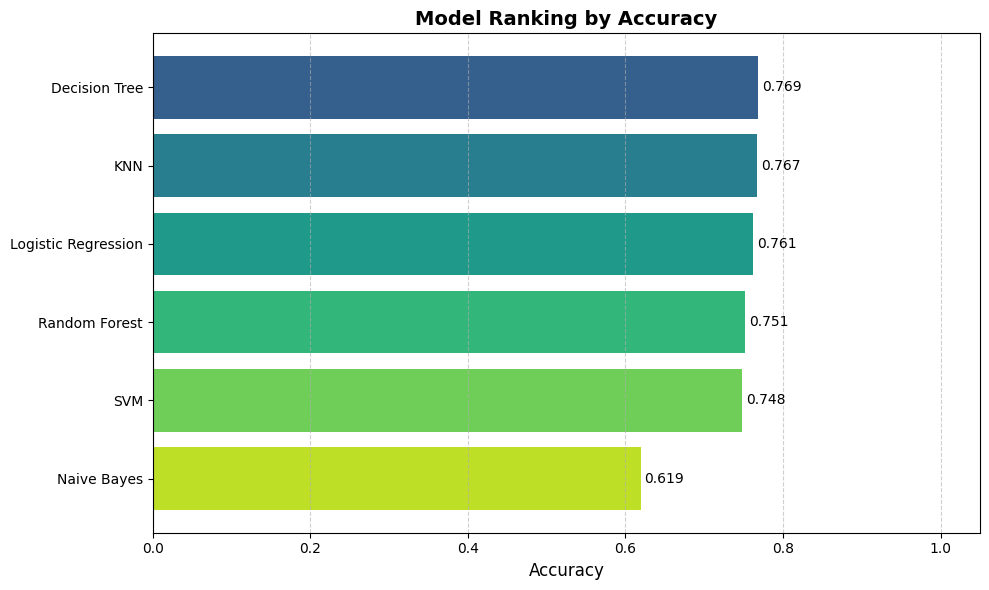

/tmp/ipykernel_3986/3434816034.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(df_results['Model'], rotation=30, ha='right')
/tmp/ipykernel_3986/3434816034.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(df_results['Model'], rotation=30, ha='right')


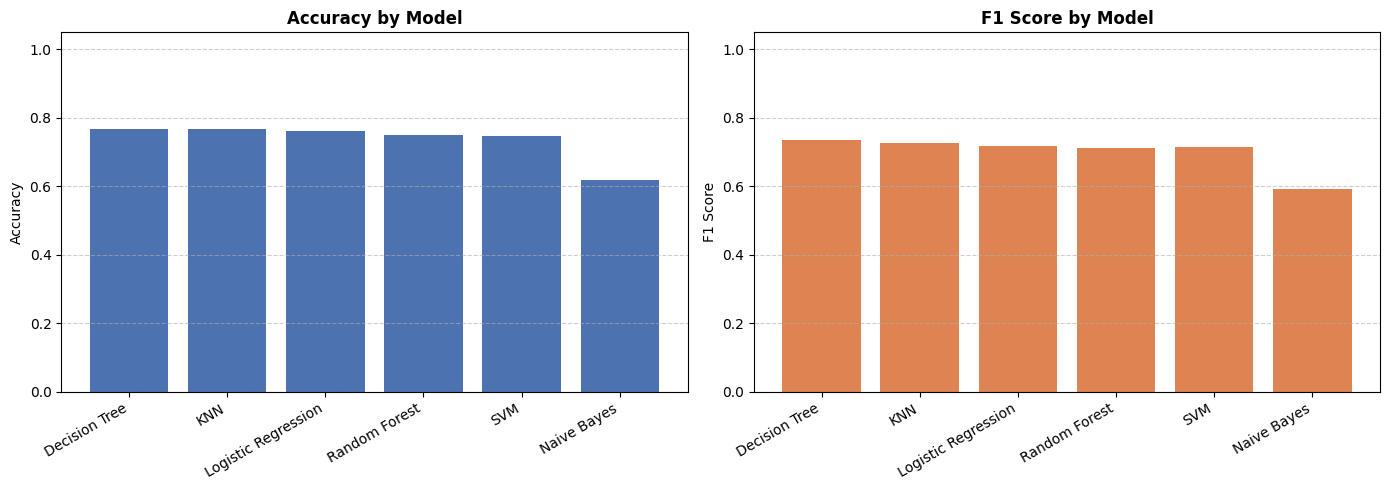

In [ ]:
df_results = pd.DataFrame(results).T.reset_index()
df_results.columns = ['Model', 'Accuracy', 'F1']
df_results = df_results.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print(df_results)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_results['Model']))
width = 0.35

bars1 = ax.bar(x - width/2, df_results['Accuracy'], width, label='Accuracy', color='#4C72B0')
bars2 = ax.bar(x + width/2, df_results['F1'],       width, label='F1 Score', color='#DD8452')
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Accuracy vs F1 Score', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_results['Model'], rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150)
plt.show()
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(df_results)))

bars = ax.barh(df_results['Model'], df_results['Accuracy'], color=colors)
ax.invert_yaxis()

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.005, bar.get_y() + bar.get_height()/2,
            f'{w:.3f}', va='center', fontsize=10)

ax.set_xlabel('Accuracy', fontsize=12)
ax.set_title('Model Ranking by Accuracy', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('model_ranking.png', dpi=150)
plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Accuracy
axes[0].bar(df_results['Model'], df_results['Accuracy'], color='#4C72B0')
axes[0].set_title('Accuracy by Model', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticklabels(df_results['Model'], rotation=30, ha='right')
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
# F1
axes[1].bar(df_results['Model'], df_results['F1'], color='#DD8452')
axes[1].set_title('F1 Score by Model', fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_xticklabels(df_results['Model'], rotation=30, ha='right')
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('accuracy_f1_subplots.png', dpi=150)
plt.show()


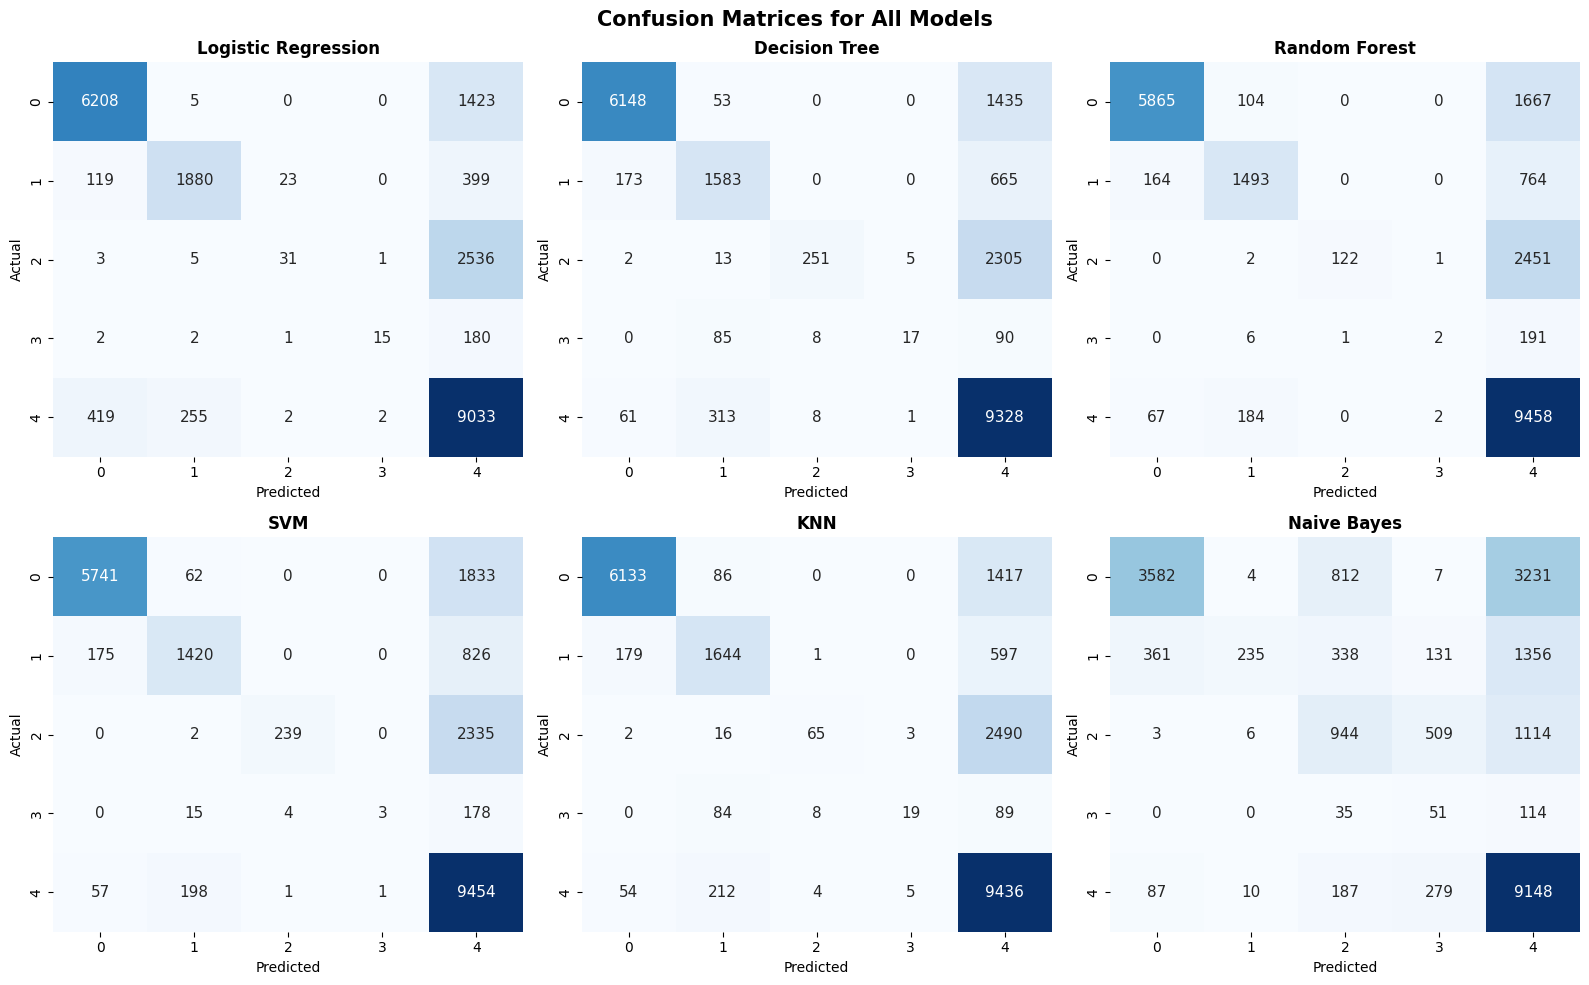

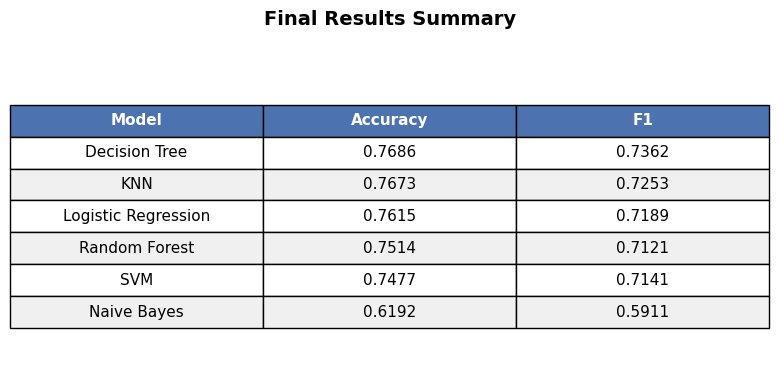

In [ ]:
conf_matrices = {}
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_test)
    conf_matrices[name] = confusion_matrix(y_test, pred)
n_models = len(conf_matrices)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, cm) in enumerate(conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                cbar=False, annot_kws={'size': 11})
    axes[i].set_title(name, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices for All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')

table = ax.table(cellText=df_results.round(4).values,
                 colLabels=df_results.columns,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 1.8)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4C72B0')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#f0f0f0' if row % 2 == 0 else 'white')

plt.title('Final Results Summary', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('results_table.png', dpi=150, bbox_inches='tight')
plt.show()

**Feature importance**

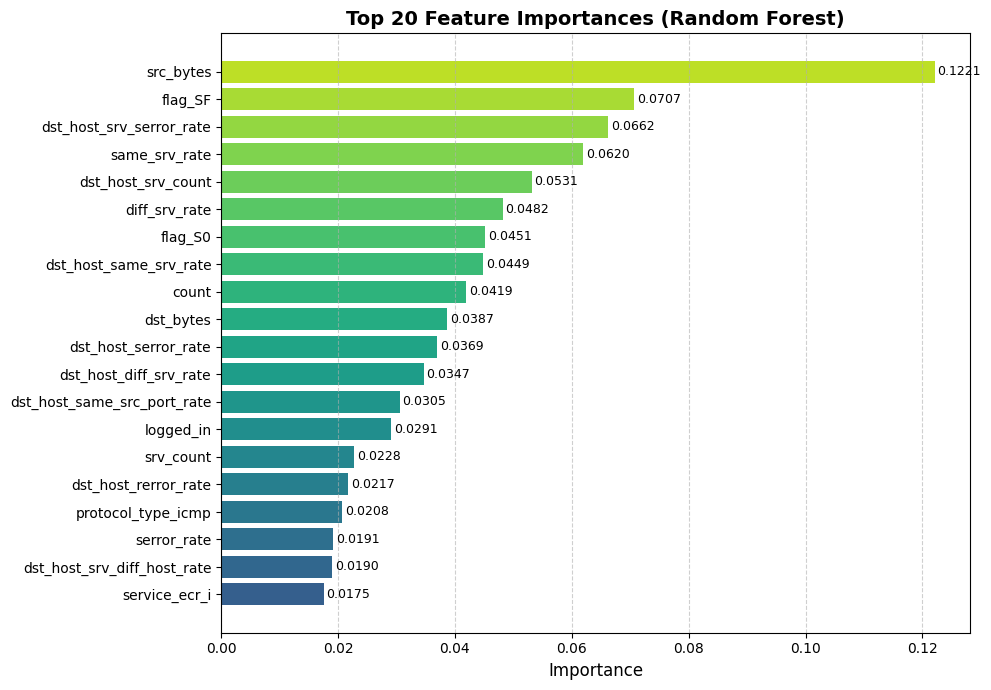


===== Top 20 Features (Random Forest) =====
 1. src_bytes                                0.12210
 2. flag_SF                                  0.07070
 3. dst_host_srv_serror_rate                 0.06621
 4. same_srv_rate                            0.06195
 5. dst_host_srv_count                       0.05312
 6. diff_srv_rate                            0.04817
 7. flag_S0                                  0.04513
 8. dst_host_same_srv_rate                   0.04485
 9. count                                    0.04188
10. dst_bytes                                0.03867
11. dst_host_serror_rate                     0.03695
12. dst_host_diff_srv_rate                   0.03466
13. dst_host_same_src_port_rate              0.03053
14. logged_in                                0.02914
15. srv_count                                0.02282
16. dst_host_rerror_rate                     0.02170
17. protocol_type_icmp                       0.02077
18. serror_rate                              0.01913
1

In [ ]:
# ---------- Train Random Forest pipe ----------
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pipe = Pipeline([('prep', preprocessor), ('clf', rf_clf)])
rf_pipe.fit(X_tr, y_tr)
# ---------- Extract prep & clf from RF pipe ----------
prep = rf_pipe.named_steps['prep']
clf  = rf_pipe.named_steps['clf']
# ---------- Feature names ----------
feature_names = num_cols + list(
    prep.named_transformers_['cat'].get_feature_names_out(cat_cols)
)
# ---------- Importances ----------
importances = clf.feature_importances_
idx = np.argsort(importances)[-20:]
# ---------- Plot ----------
plt.figure(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(idx)))
bars = plt.barh(range(len(idx)), importances[idx], color=colors)
# Value labels
for i, bar in enumerate(bars):
    w = bar.get_width()
    plt.text(w + 0.0005, bar.get_y() + bar.get_height()/2,
             f'{w:.4f}', va='center', fontsize=9)
plt.yticks(range(len(idx)), [feature_names[i] for i in idx])
plt.xlabel('Importance', fontsize=12)
plt.title('Top 20 Feature Importances (Random Forest)',
          fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('rf_top20_features.png', dpi=150)
plt.show()
# ---------- Print ranking ----------
print("\n===== Top 20 Features (Random Forest) =====")
for rank, i in enumerate(idx[::-1], 1):
    print(f"{rank:2d}. {feature_names[i]:<40s} {importances[i]:.5f}")

**Class distribution and KDDTest-21 comparison**


In [ ]:
# Compare full test vs KDDTest-21
test21 = pd.read_csv('KDDTest-21.txt', names=col_names)
test21['category'] = test21['label'].apply(map_attack)

print("KDDTest+ shape:", test.shape)
print("KDDTest-21 shape:", test21.shape)
print(test21['category'].value_counts())

KDDTest+ shape: (22544, 45)
KDDTest-21 shape: (11850, 44)
category
DoS       4520
R2L       2576
Probe     2402
normal    2152
U2R        200
Name: count, dtype: int64


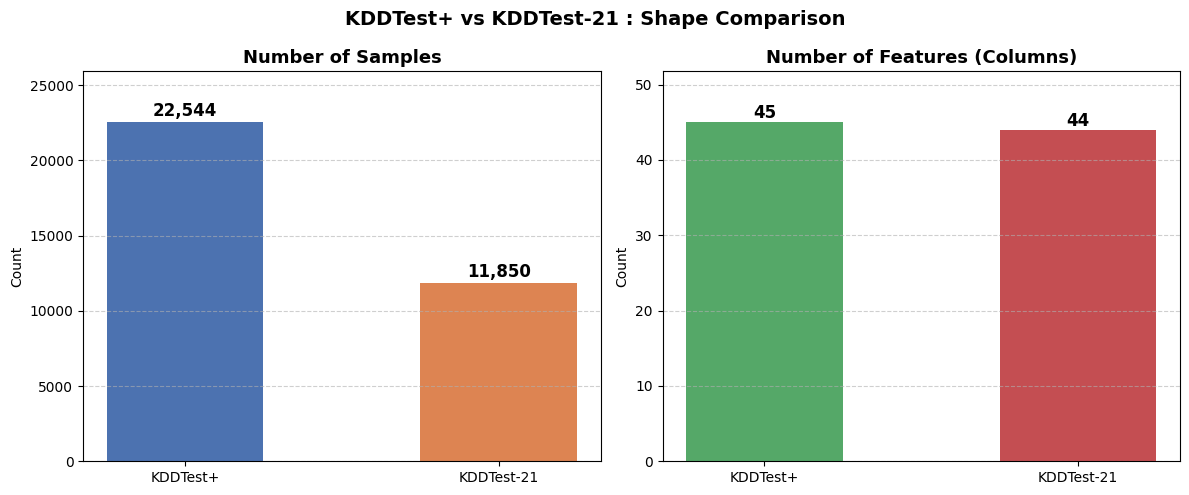

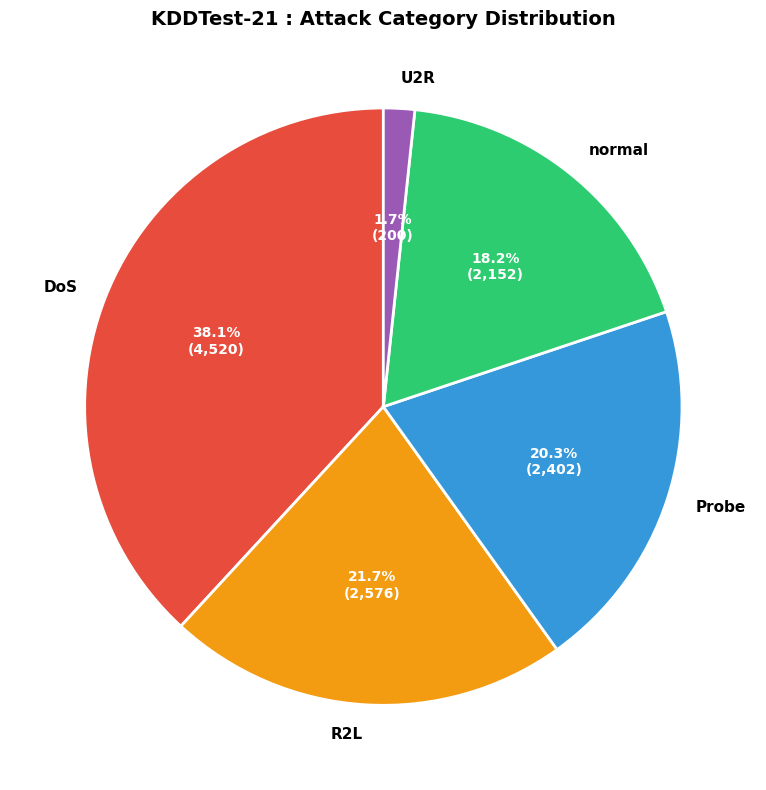

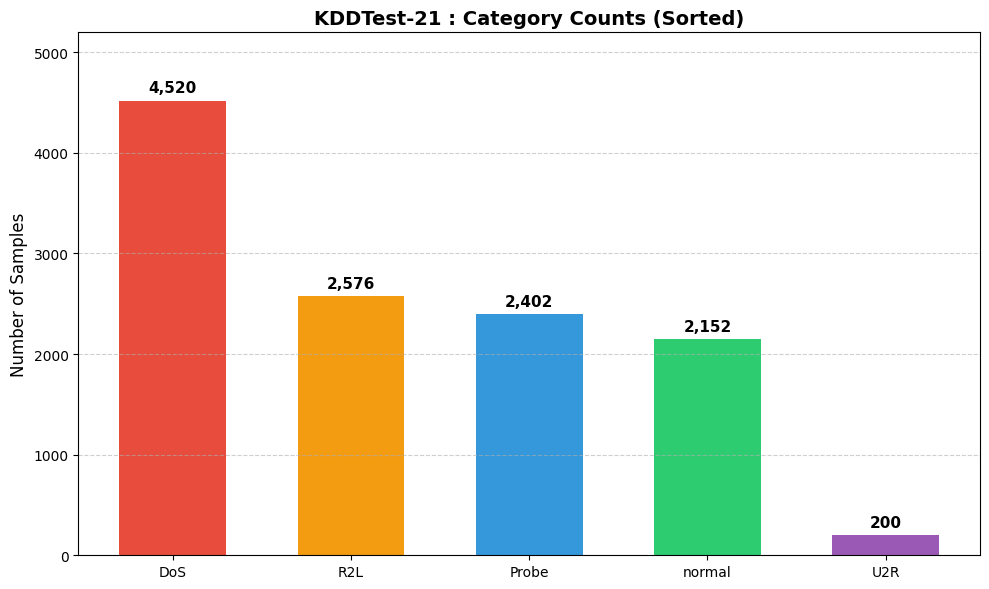

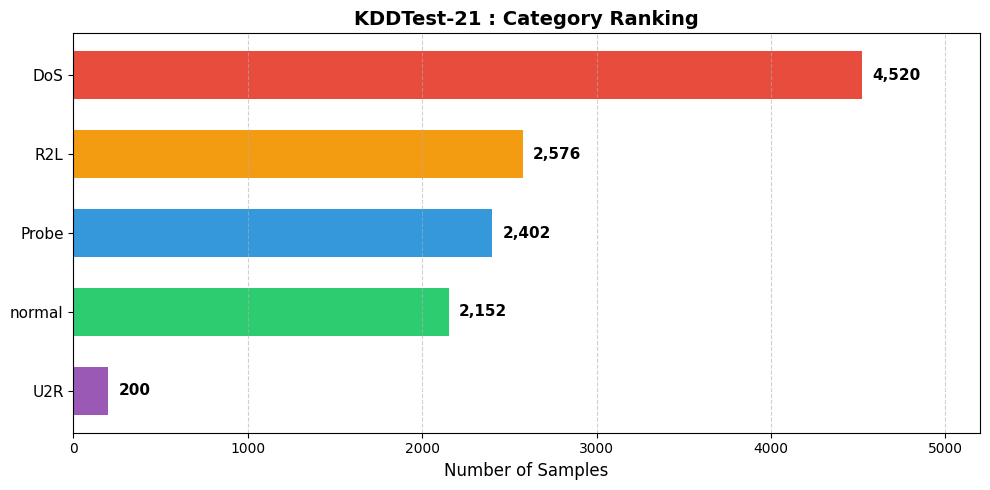

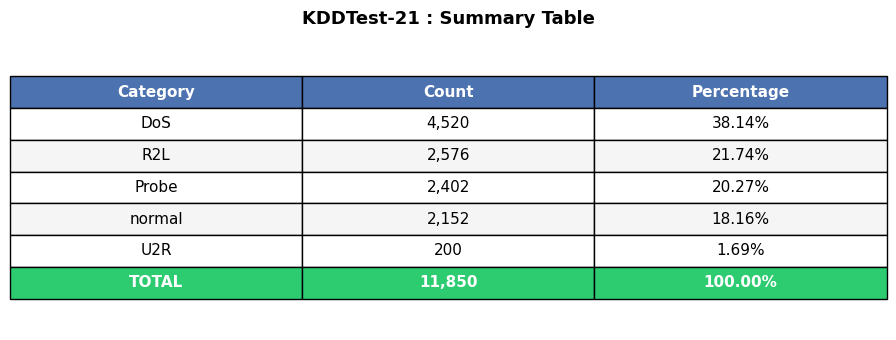

In [ ]:
datasets = ['KDDTest+', 'KDDTest-21']
samples  = [22544, 11850]
features = [45, 44]

categories = ['DoS', 'R2L', 'Probe', 'normal', 'U2R']
counts     = [4520, 2576, 2402, 2152, 200]
colors     = ['#E74C3C', '#F39C12', '#3498DB', '#2ECC71', '#9B59B6']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Samples
bars = axes[0].bar(datasets, samples, color=['#4C72B0', '#DD8452'], width=0.5)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 400,
                 f'{h:,}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Number of Samples', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(samples) * 1.15)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Features
bars = axes[1].bar(datasets, features, color=['#55A868', '#C44E52'], width=0.5)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                 f'{h}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Number of Features (Columns)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(features) * 1.15)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('KDDTest+ vs KDDTest-21 : Shape Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shape_comparison.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    counts,
    labels=categories,
    autopct=lambda p: f'{p:.1f}%\n({int(round(p*sum(counts)/100)):,})',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_color('white')

ax.set_title('KDDTest-21 : Attack Category Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kddtest21_pie.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

# sort descending
sorted_data = sorted(zip(categories, counts, colors),
                     key=lambda x: x[1], reverse=True)
cats_s, counts_s, colors_s = zip(*sorted_data)

bars = ax.bar(cats_s, counts_s, color=colors_s, width=0.6)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 80,
            f'{int(h):,}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('KDDTest-21 : Category Counts (Sorted)',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts_s) * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('kddtest21_counts.png', dpi=150)
plt.show()
fig, ax = plt.subplots(figsize=(10, 5))

y_pos = np.arange(len(cats_s))
bars = ax.barh(y_pos, counts_s, color=colors_s, height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(cats_s, fontsize=11)
ax.invert_yaxis()

for bar in bars:
    w = bar.get_width()
    ax.text(w + 60, bar.get_y() + bar.get_height()/2,
            f'{int(w):,}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Number of Samples', fontsize=12)
ax.set_title('KDDTest-21 : Category Ranking',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, max(counts_s) * 1.15)
ax.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('kddtest21_ranking.png', dpi=150)
plt.show()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.axis('off')

total = sum(counts)
table_data = []
for c, n in zip(categories, counts):
    table_data.append([c, f'{n:,}', f'{n/total*100:.2f}%'])
table_data.append(['TOTAL', f'{total:,}', '100.00%'])

table = ax.table(cellText=table_data,
                 colLabels=['Category', 'Count', 'Percentage'],
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4C72B0')
        cell.set_text_props(color='white', fontweight='bold')
    elif row == len(table_data):
        cell.set_facecolor('#2ECC71')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#F5F5F5' if row % 2 == 0 else 'white')

ax.set_title('KDDTest-21 : Summary Table',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('summary_table.png', dpi=150, bbox_inches='tight')
plt.show()

**Complete Attack Type Mapping (Part 1.2)**

In [ ]:
attack_map = {
    'DoS': ['apache2', 'back', 'mailbomb', 'processtable', 'snmpgetattack',
            'teardrop', 'smurf', 'land', 'neptune', 'pod', 'udpstorm'],
    'Probe': ['nmap', 'ipsweep', 'portsweep', 'satan', 'mscan', 'saint'],
    'R2L': ['ftp_write', 'guess_passwd', 'snmpguess', 'imap', 'spy',
            'warezclient', 'warezmaster', 'multihop', 'phf', 'named',
            'sendmail', 'xlock', 'xsnoop', 'worm'],
    'U2R': ['ps', 'buffer_overflow', 'perl', 'rootkit', 'loadmodule',
            'xterm', 'sqlattack', 'httptunnel']
}

**Data Quality Checks (Part 2)**

In [ ]:
# Check missing values
print(train.isnull().sum().sum(), test.isnull().sum().sum())
# Check duplicates
print("Train duplicates:", train.duplicated().sum())
print("Test duplicates:", test.duplicated().sum())
# Check data types
print(train.dtypes.value_counts())
# Check class distribution
print(train['label'].value_counts())
print(test['label'].value_counts())

0 0
Train duplicates: 0
Test duplicates: 0
int64      25
float64    15
object      5
Name: count, dtype: int64
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64
label
normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint       

**Class Imbalance Handling (Part 3)**

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
pipe = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])
pipe.fit(X_tr, y_tr)
pred = pipe.predict(X_test)

**ROC Curve and AUC for Binary Classification**



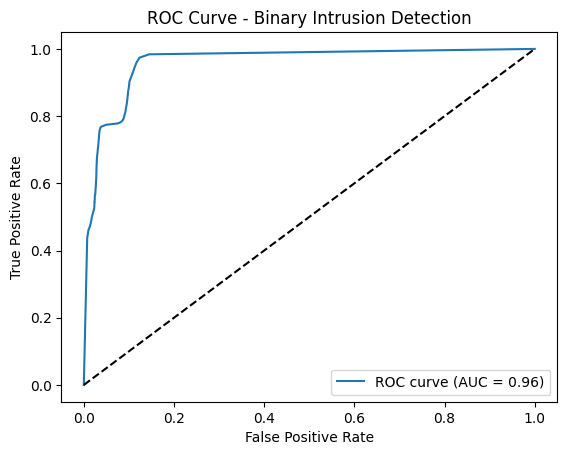

In [ ]:
from sklearn.metrics import roc_curve, auc
# Train binary model
y_train_bin = train['binary']
y_test_bin = test['binary']

pipe_bin = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])
pipe_bin.fit(X_train, y_train_bin)

y_prob = pipe_bin.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Binary Intrusion Detection')
plt.legend()
plt.show()

**Cross-Validation (Part 2 & 3)**

In [ ]:
from sklearn.model_selection import cross_val_score
pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1_weighted')
print("Cross-validation F1 scores:", scores)
print("Mean F1:", scores.mean())

Cross-validation F1 scores: [0.99890678 0.99899973 0.99862952 0.99879691 0.99901191]
Mean F1: 0.998868971016248


**Hyperparameter Tuning (Part 3)**

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5]
}

grid = GridSearchCV(pipe, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1)
grid.fit(X_tr, y_tr)
print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 50}
Best score: 0.9983604101138942
